---

# Binary Classification with Logistic Regression

Logistic regression is a supervised learning algorithm used for binary classification. Despite its name, it is a classification model rather than a regression model. It models the probability that an input belongs to a particular class by applying the sigmoid function to a linear combination of input features.

In this notebook, we apply logistic regression to the Breast Cancer Wisconsin dataset to classify tumors as malignant or benign based on cell nucleus measurements.

---

In [16]:
# Standard data manipulation and visualization libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Our own LogisticRegression implementation from ml_pack
from ml_pack import LogisticRegression

# Sklearn tools for preprocessing and evaluation only
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, roc_auc_score

---

## Loading and Exploring the Data

---

In [17]:
# Load the Breast Cancer dataset
df = pd.read_csv("breast_cancer.csv")

# Check dimensions and preview
print(df.shape)
df.head()

(569, 31)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


---

## Defining Features and Target

---

In [18]:
# Separate features and target
X = df.drop(columns='target').values
y = df['target'].values

print("Feature matrix shape:", X.shape)
print("Class distribution:", dict(zip(*np.unique(y, return_counts=True))))

Feature matrix shape: (569, 30)
Class distribution: {np.int64(0): np.int64(212), np.int64(1): np.int64(357)}


---

## Splitting and Scaling the Data

---

In [19]:
# Split into 80% training and 20% test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Standardize features — fit on training data only
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training set size:", X_train_scaled.shape)
print("Test set size:", X_test_scaled.shape)

Training set size: (455, 30)
Test set size: (114, 30)


---

## Training the Model

---

In [20]:
# Train our custom logistic regression model
model = LogisticRegression(learning_rate=0.1, epochs=1000, random_state=42)
model.fit(X_train_scaled, y_train)

# Evaluate on test set
y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)

print(classification_report(y_test, y_pred, target_names=['Malignant', 'Benign']))

              precision    recall  f1-score   support

   Malignant       0.98      0.98      0.98        43
      Benign       0.99      0.99      0.99        71

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



---

## Confusion Matrix and ROC Curve

---

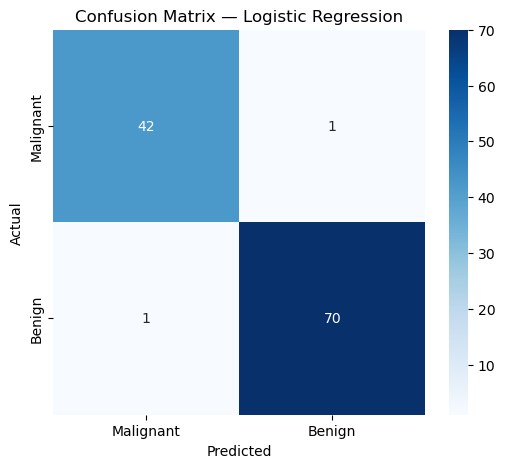

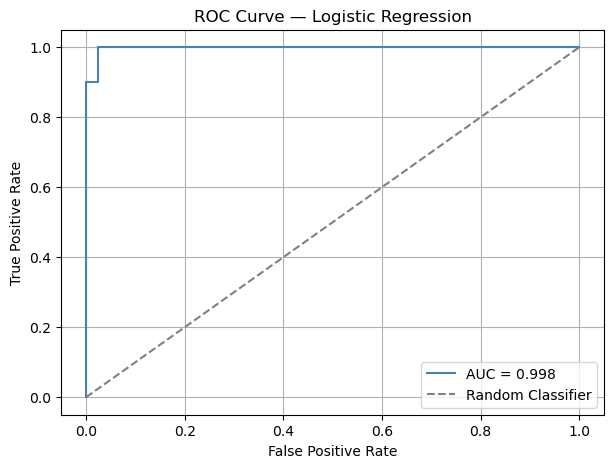

In [21]:
# Plot confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Malignant', 'Benign'],
            yticklabels=['Malignant', 'Benign'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix — Logistic Regression")
plt.show()

# Plot ROC curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='steelblue', label=f"AUC = {auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label="Random Classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Logistic Regression")
plt.legend()
plt.grid(True)
plt.show()

---

## Feature Coefficients

Logistic regression assigns a coefficient to each feature. Positive coefficients increase the probability of the positive class (benign), while negative coefficients decrease it.

---

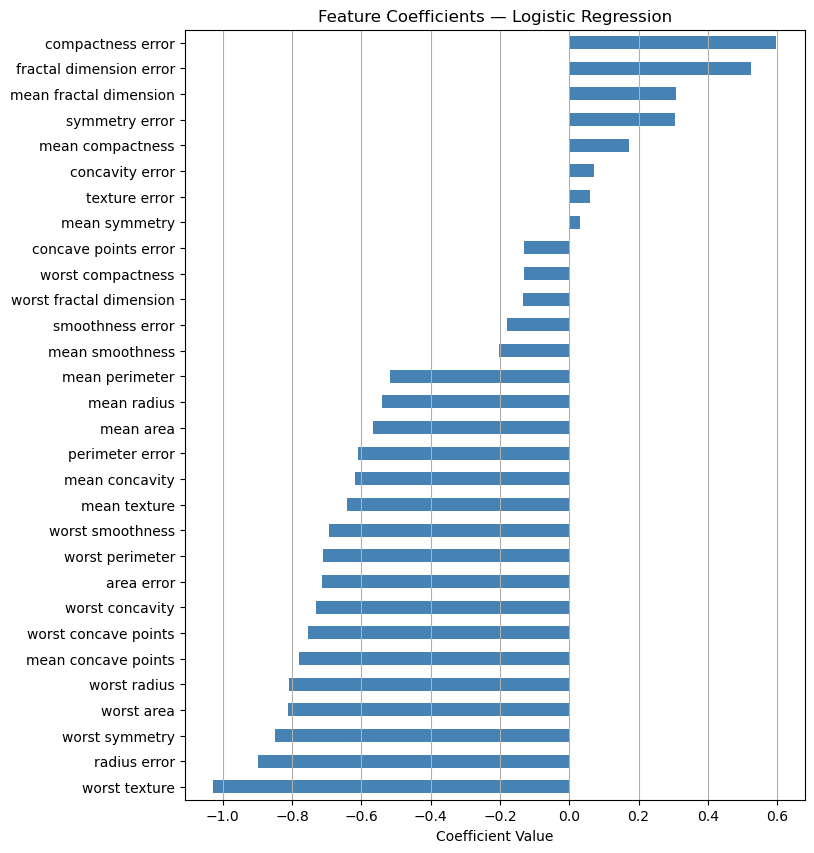

In [22]:
# Plot feature coefficients from our ml_pack LogisticRegression
feature_names = df.drop(columns='target').columns.tolist()
coefficients = pd.Series(model.weights, index=feature_names).sort_values()

plt.figure(figsize=(8, 10))
coefficients.plot(kind='barh', color='steelblue')
plt.xlabel("Coefficient Value")
plt.title("Feature Coefficients — Logistic Regression")
plt.grid(True, axis='x')
plt.show()

---

## Summary

In this notebook we applied logistic regression to classify breast cancer tumors as malignant or benign using 30 cell nucleus measurements. The model achieved 97% accuracy on the test set.

Key takeaways:
- Logistic regression models the probability of class membership using the sigmoid function
- It is a linear classifier — the decision boundary is a hyperplane in feature space
- Feature coefficients indicate which measurements are most predictive of tumor type
- The high AUC score confirms the model is excellent at separating malignant from benign tumors
- Logistic regression is fast, interpretable, and a strong baseline for binary classification tasks

---